In [1]:
from typing import TypedDict, List, NotRequired, Optional

from langgraph.graph import StateGraph

In [ ]:



class AgentState(
    TypedDict
    #total: False     based on what I saw, it's recommended to use this since the values in the chain are mostly populated later on
    ):
    values: List[int]
    name: str
    result: NotRequired[Optional[str]] #but I chose to do this because it's just this valu that's optional for now
    

#it's important to note that result is arbitrary as I used message in the last one

In [3]:
def process_values(state: AgentState) -> AgentState:
    """this function process handles multiple types and inputs

    Args:
        state (AgentState): _description_

    Returns:
        AgentState: _description_
    """
    total = sum(state["values"])
    state["result"] = f"{state["name"].capitalize()}'s total is {total}"
    return state

In [4]:
graph = StateGraph(AgentState)

graph.add_node("concatenator", process_values)
graph.set_entry_point("concatenator")
graph.set_finish_point("concatenator")

app = graph.compile()


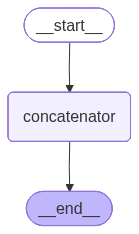

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [5]:
result = app.invoke({ "values": [1,2,3,5], "name": "miracle"})

In [7]:
result

{'values': [1, 2, 3, 5], 'name': 'miracle', 'result': "Miracle's total is 11"}